# Семантический поиск по песням (Day 2 NLP — YDL 2026)

Ищем песни **по смыслу**, а не по точным словам: эмбеддинги **GloVe** + **косинусная близость**.
Стиль и функции скопированы из `lab_embeddings_toolbox.ipynb` (raid the toolbox).

## Часть 0 — Подготовка (установка + импорты)

Ставим библиотеки (один раз) и импортируем рабочие инструменты:
`gensim` (готовые эмбеддинги), `scikit-learn` (PCA/t-SNE для карты), `matplotlib`, `pandas`.

In [7]:
# Если каких-то библиотек нет, раскомментируй и запусти один раз:
# %pip install gensim scikit-learn matplotlib pandas

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim.downloader as api            # готовые эмбеддинги (GloVe)
from sklearn.decomposition import PCA      # проекция в 2D для карты
from sklearn.manifold import TSNE          # альтернативная проекция в 2D

# воспроизводимость + папка для картинок (как в ноутбуке-тулбоксе)
np.random.seed(0)
os.makedirs("outputs", exist_ok=True)

print("ready")

ready


## Часть 1 — Загрузить данные (свой текст)

Грузим 2000 песен из `song_lyrics_sample_2000.csv` и достаём три списка:
**`lyrics`** (тексты — корпус для поиска), **`moods`** (настроение — для раскраски карты),
**`labels`** (читаемое имя «Артист — Песня»).

In [8]:
# путь к датасету (лежит рядом с ноутбуком)
CSV = "song_lyrics_sample_2000.csv"
if not os.path.exists(CSV):  # запасной путь, если рабочая папка — корень проекта
    CSV = os.path.join("yessenov_data_lab_program", "Day11", CSV)

df = pd.read_csv(CSV)
print("Загружено песен:", len(df))


def niceLabel(fn):
    "'Artist___Song_Name' -> 'Artist - Song Name'"
    return " - ".join(p.replace("_", " ") for p in str(fn).split("___"))


lyrics = df["lyrics"].astype(str).tolist()                 # корпус: одна песня = один текст
moods  = df["mood"].astype(str).tolist()                   # метка настроения (для карты)
labels = [niceLabel(fn) for fn in df["lyrics_filename"]]   # читаемое имя песни

# быстрый осмотр
print("настроения:", sorted(set(moods)))
print("\nпример песни:")
print("  label :", labels[0])
print("  mood  :", moods[0])
print("  lyrics:", lyrics[0][:160], "...")

Загружено песен: 2000
настроения: ['anger', 'calm', 'happy', 'sad']

пример песни:
  label : Katatonia - I Transpire
  mood  : sad
  lyrics: "I Transpire LyricsI\nCan't\nSay that I am free\nAs long as they return\nIf I\nHad\nA way out of here\nWould I then return?\nThey seldom will speak, no\nThey on ...


## Часть 2 — Загрузить GloVe (готовые эмбеддинги)

Берём предобученные векторы `glove-wiki-gigaword-100` (как в §1 ноутбука-тулбокса):
400 000 слов, по 100 чисел на слово (~128 МБ — первый раз качается, потом из кеша).
**Ничего не обучаем** — просто загружаем готовую «таблицу слово → вектор» в `wv`.

In [9]:
# качает ~128 МБ при первом запуске, дальше грузит из кеша (у тебя уже в кеше)
try:
    wv = api.load("glove-wiki-gigaword-100")
    print("loaded", len(wv.index_to_key), "word vectors, each of dimension", wv.vector_size)
except Exception as e:
    print("не удалось скачать эмбеддинги, есть ли интернет?", e)
    wv = None

# мини-проверка, что векторы осмысленные (как в ноутбуке)
if wv is not None:
    print("проверка: similarity(cat, dog) =", round(wv.similarity("cat", "dog"), 3))

loaded 400000 word vectors, each of dimension 100
проверка: similarity(cat, dog) = 0.88


## Часть 3 — Превратить каждую песню в вектор

Используем функцию **`documentVector`** из §5a ноутбука: песня → среднее эмбеддингов её слов
(один вектор из 100 чисел). Перед этим лёгкая чистка `cleanTokens`: убираем `\n`-мусор и
пунктуацию, оставляем только слова. На выходе — матрица **`songVectors`** размера (2000, 100).

In [10]:
import re


def cleanTokens(text):
    "нижний регистр + только буквенные слова (убирает \\n-мусор и пунктуацию)"
    text = text.lower().replace("\\n", " ")   # literal \n из текстов песен -> пробел
    return re.findall(r"[a-z]+", text)


def documentVector(text, wv):
    "песня -> один вектор: среднее эмбеддингов её слов (как в §5a ноутбука)"
    tokens = [t for t in cleanTokens(text) if t in wv]
    if not tokens:
        return np.zeros(wv.vector_size)
    return np.mean([wv[t] for t in tokens], axis=0)


# векторизуем все песни -> матрица (2000, 100)
songVectors = np.array([documentVector(t, wv) for t in lyrics])
print("матрица векторов песен:", songVectors.shape)

nonzero = int((np.linalg.norm(songVectors, axis=1) > 0).sum())
print(f"песен с валидным вектором: {nonzero} из {len(songVectors)}")
print("пример токенов песни 0:", cleanTokens(lyrics[0])[:12])

матрица векторов песен: (2000, 100)
песен с валидным вектором: 2000 из 2000
пример токенов песни 0: ['i', 'transpire', 'lyricsi', 'can', 't', 'say', 'that', 'i', 'am', 'free', 'as', 'long']


## Часть 4 — Собрать поисковик (сердце проекта)

Копируем **`cosineSim`** и **`nearestNeighbors`** из §2 ноутбука. `nearestNeighbors` —
это уже почти готовый поисковик: берёт вектор-запрос, список векторов и их метки и
возвращает топ-N ближайших. Мы подаём в него **векторы песен** (а не слов) и оборачиваем
в `search()` / `showResults()`.

In [11]:
# --- скопировано из §2 ноутбука ---
def cosineSim(a, b):
    "косинусная близость двух векторов (вручную на numpy, как в ноутбуке)"
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


def nearestNeighbors(vec, vectors, words, topn=5):
    "вернуть topn элементов, чьи векторы ближе всего к vec по косинусу"
    scored = [(w, cosineSim(vec, vectors[i])) for i, w in enumerate(words)]
    scored.sort(key=lambda p: p[1], reverse=True)
    return scored[:topn]


# --- наша обёртка: поиск ПЕСЕН по смыслу ---
def search(query, topn=5):
    "вернуть [(индекс_песни, score)] topn песен, ближайших по смыслу к запросу"
    qvec = documentVector(query, wv)
    return nearestNeighbors(qvec, songVectors, list(range(len(songVectors))), topn)


def showResults(query, topn=5):
    "красиво напечатать результаты поиска"
    print(f'Запрос: "{query}"')
    for rank, (i, score) in enumerate(search(query, topn), 1):
        print(f"  {rank}. {score:.3f}  [{moods[i]:5s}]  {labels[i]}")


# быстрый тест
showResults("heartbreak and loneliness")

Запрос: "heartbreak and loneliness"
  1. 0.720  [sad  ]  Enigma - I Love YouILl Kill You
  2. 0.715  [calm ]  Art Of Noise - Love
  3. 0.677  [calm ]  HIM - In Joy And Sorrow
  4. 0.677  [happy]  Brian McKnight - Crazy Love
  5. 0.676  [anger]  Arch Enemy - Lament Of A Mortal Soul


## Часть 5 — Проверка: гоняем разные запросы

Запускаем несколько запросов и смотрим глазами, осмысленные ли результаты.
Замечаем: слова из запроса часто **вообще не встречаются** в названии песни — движок
находит по смыслу. Запрос про молитву → религиозные песни, про вечеринку → весёлые.

In [13]:
for q in [
    "heartbreak and loneliness",      # ждём грустное
    "Diamond shine",      # ждём весёлое
    "war fight anger blood",          # ждём агрессивное
    "god heaven faith prayer",        # ждём религиозное
    "summer sunshine beach ocean",    # ждём про лето / океан
]:
    showResults(q)
    print()

Запрос: "heartbreak and loneliness"
  1. 0.720  [sad  ]  Enigma - I Love YouILl Kill You
  2. 0.715  [calm ]  Art Of Noise - Love
  3. 0.677  [calm ]  HIM - In Joy And Sorrow
  4. 0.677  [happy]  Brian McKnight - Crazy Love
  5. 0.676  [anger]  Arch Enemy - Lament Of A Mortal Soul

Запрос: "Diamond shine"
  1. 0.572  [sad  ]  Colony 5 - Black single Edit
  2. 0.560  [sad  ]  Joni Mitchell - Shine
  3. 0.548  [sad  ]  John Carpenter - Seasons
  4. 0.542  [calm ]  Hayley Westenra - Dark Waltz
  5. 0.541  [calm ]  Devendra Banhart - Owl Eyes

Запрос: "war fight anger blood"
  1. 0.808  [sad  ]  Hawkwind - Zarozinia
  2. 0.808  [happy]  Eftos - SelfDestruct Intelligence
  3. 0.807  [anger]  At The Gates - Terminal Spirit Disease
  4. 0.806  [happy]  Hatebreed - Final Prayer
  5. 0.805  [happy]  DEWSCENTED - New found pain

Запрос: "god heaven faith prayer"
  1. 0.713  [happy]  Aaron Shust - My Savior My God
  2. 0.702  [sad  ]  Gary Numan - My Jesus
  3. 0.692  [sad  ]  Evanescence - Tourn

## Часть 6 — Артефакт: картинка для сдачи

**Главный артефакт** — горизонтальный бар-чарт **топ-10 песен** для запроса: длина столбца =
близость по смыслу, цвет = настроение песни. Наглядно показывает, что поиск ранжирует песни
по смыслу. Сохраняем в `outputs/` для сдачи.

Ниже (бонус) — обзорная **карта всех 2000 песен** + честное наблюдение о том, что
усреднённые эмбеддинги ловят **тему**, а не **настроение**.

сохранено: outputs/search_results.png


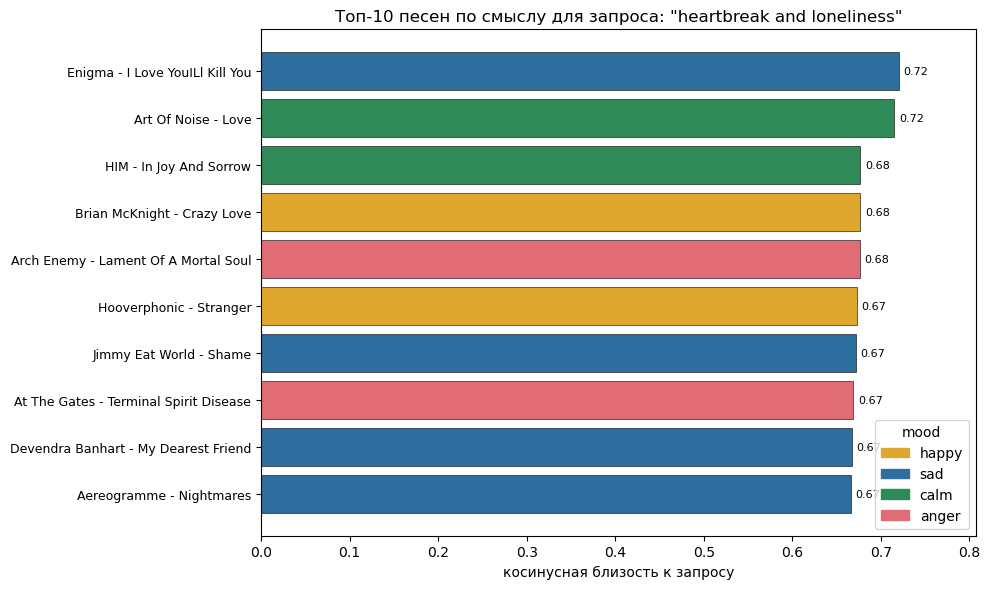

In [14]:
import matplotlib.patches as mpatches

palette = {"happy": "#e0a72f", "sad": "#2f6f9f", "calm": "#2e8b57", "anger": "#e06c75"}


def plotTopResults(query, topn=10, save=None):
    "бар-чарт топ-N песен по близости к запросу; цвет столбца = настроение"
    res = search(query, topn)                     # [(индекс_песни, score)]
    idx   = [i for i, _ in res]
    score = [s for _, s in res]
    y = np.arange(topn)[::-1]                      # ранг 1 — наверху
    colors = [palette[moods[i]] for i in idx]

    plt.figure(figsize=(10, 6))
    plt.barh(y, score, color=colors, edgecolor="black", linewidth=0.4)
    plt.yticks(y, [labels[i] for i in idx], fontsize=9)
    plt.xlabel("косинусная близость к запросу")
    plt.title(f'Топ-{topn} песен по смыслу для запроса: "{query}"')
    plt.xlim(0, max(score) * 1.12)
    for yi, s in zip(y, score):
        plt.text(s + 0.005, yi, f"{s:.2f}", va="center", fontsize=8)
    handles = [mpatches.Patch(color=c, label=m) for m, c in palette.items()]
    plt.legend(handles=handles, title="mood", loc="lower right")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=130)
        print("сохранено:", save)
    plt.show()


# ГЛАВНЫЙ артефакт (поменяй запрос на свой)
plotTopResults("heartbreak and loneliness", topn=10, save="outputs/search_results.png")

### Бонус — обзорная карта всех песен (и честное наблюдение)

Проецируем все 2000 векторов в 2D (t-SNE, как в §3a/§4a ноутбука) и красим по настроению.
**Цвета перемешаны** — это честный результат: усреднённые статические эмбеддинги ловят
**тему/лексику**, а не **настроение** (песня про «love» может быть и happy, и sad). Это
ожидаемый предел метода, и его полезно показать в отчёте. *t-SNE на 2000 точек ~30 сек.*

сохранено: outputs/song_map.png


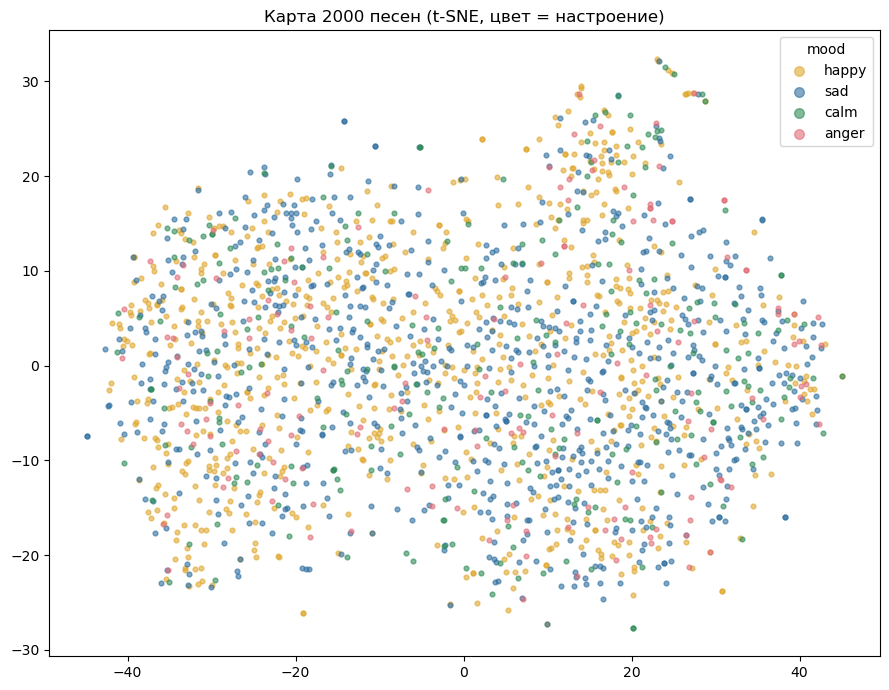

In [18]:
# проекция всех песен в 2D (t-SNE ~30 сек). Для быстрого варианта замени на:
# coords = PCA(n_components=2).fit_transform(songVectors)
coords = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(songVectors)

moods_arr = np.array(moods)
plt.figure(figsize=(9, 7))
for m, color in palette.items():
    mask = moods_arr == m
    plt.scatter(coords[mask, 0], coords[mask, 1], s=12, color=color, alpha=0.6, label=m)
plt.legend(title="mood", markerscale=2)
plt.title("Карта 2000 песен (t-SNE, цвет = настроение)")
plt.tight_layout()
plt.savefig("outputs/song_map.png", dpi=130)
print("сохранено: outputs/song_map.png")
plt.show()

## Часть 7 — Вывод (что получилось)

Я собрал **семантический поисковик по 2000 песням**: каждую песню превратил в вектор через
усреднение GloVe-эмбеддингов её слов (`documentVector`) и ранжирую песни по **косинусной
близости** к текстовому запросу (`cosineSim` + `nearestNeighbors`). Поиск работает **по смыслу,
а не по словам**: например, на запрос *«god heaven faith prayer»* движок вернул *«My Savior My
God»*, *«My Jesus»*, *«The Sacrament»* — религиозные песни, хотя точные слова запроса в их
названиях не встречаются. Запрос про вечеринку выдаёт весёлые треки, про войну — агрессивный
метал: семантика действительно ловится.

**Честное наблюдение (где метод ломается):** на обзорной 2D-карте песни **не разделяются по
настроению** — цвета перемешаны. Это ожидаемо: усреднённые статические эмбеддинги отражают
**тему и лексику**, а не эмоцию; вдобавок усреднение теряет порядок слов, а у GloVe один
вектор на слово вне контекста. Тематический поиск — сильная сторона метода, тонкое
настроение — слабая.

**Чек-лист брифа:** ✅ свой текст (2000 песен, не демо-данные) · ✅ end-to-end (загрузка →
векторы → результат) · ✅ артефакт-картинка (`outputs/search_results.png`).

## Бонус — tf-idf-взвешенные эмбеддинги (наглядное сравнение)

«Вариант A»: **тот же GloVe, но слова взвешены по tf-idf**. При усреднении частые нейтральные
слова (*the, you*) получают маленький вес, а характерные — большой. Используем **оба инструмента
сразу**: tf-idf даёт веса, GloVe даёт векторы.

Ниже сравниваем «простое среднее» (`songVectors`) vs «tf-idf-взвешенное» (`tfidfVectors`):
сначала результаты поиска, потом карту по настроению.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# тот же очищенный текст, что и для GloVe
cleaned = [" ".join(cleanTokens(t)) for t in lyrics]

# tf-idf веса каждого слова в каждой песне
vec = TfidfVectorizer(token_pattern=r"(?u)\b[a-z]+\b", min_df=2)
X = vec.fit_transform(cleaned)                   # (2000, vocab) — разреженная матрица tf-idf
vocab = vec.get_feature_names_out()

# GloVe-вектор для каждого слова словаря (нет в GloVe -> нули)
E = np.array([wv[w] if w in wv else np.zeros(wv.vector_size) for w in vocab])  # (vocab, 100)

# взвешенное среднее: (tf-idf @ GloVe) / сумму весов  ->  (2000, 100)
rowsum = np.asarray(X.sum(axis=1)).ravel()
rowsum[rowsum == 0] = 1.0
tfidfVectors = (X @ E) / rowsum[:, None]

print("plain :", songVectors.shape)
print("tfidf :", tfidfVectors.shape, "| словарь:", len(vocab), "слов")

plain : (2000, 100)
tfidf : (2000, 100) | словарь: 12282 слов


In [20]:
def compareSearch(query, topn=5):
    "печатает топ-N: простое среднее vs tf-idf-взвешенное"
    q = documentVector(query, wv)
    for name, vectors in [("ПРОСТОЕ СРЕДНЕЕ", songVectors), ("TF-IDF-ВЗВЕШЕННОЕ", tfidfVectors)]:
        sims = np.array([cosineSim(q, v) for v in vectors])
        idx = sims.argsort()[::-1][:topn]
        print(f'\n[{name}]  запрос: "{query}"')
        for rank, i in enumerate(idx, 1):
            print(f"  {rank}. {sims[i]:.3f}  [{moods[i]:5s}]  {labels[i]}")


# сравни сам, меняя запрос:
compareSearch("war fight anger blood")


[ПРОСТОЕ СРЕДНЕЕ]  запрос: "war fight anger blood"
  1. 0.808  [sad  ]  Hawkwind - Zarozinia
  2. 0.808  [happy]  Eftos - SelfDestruct Intelligence
  3. 0.807  [anger]  At The Gates - Terminal Spirit Disease
  4. 0.806  [happy]  Hatebreed - Final Prayer
  5. 0.805  [happy]  DEWSCENTED - New found pain

[TF-IDF-ВЗВЕШЕННОЕ]  запрос: "war fight anger blood"
  1. 0.830  [happy]  Eftos - SelfDestruct Intelligence
  2. 0.825  [anger]  At The Gates - Terminal Spirit Disease
  3. 0.823  [calm ]  Joe Henry - Civil War
  4. 0.822  [happy]  Hatebreed - Final Prayer
  5. 0.820  [happy]  In Strict Confidence - Hero


сохранено: outputs/compare_tfidf.png


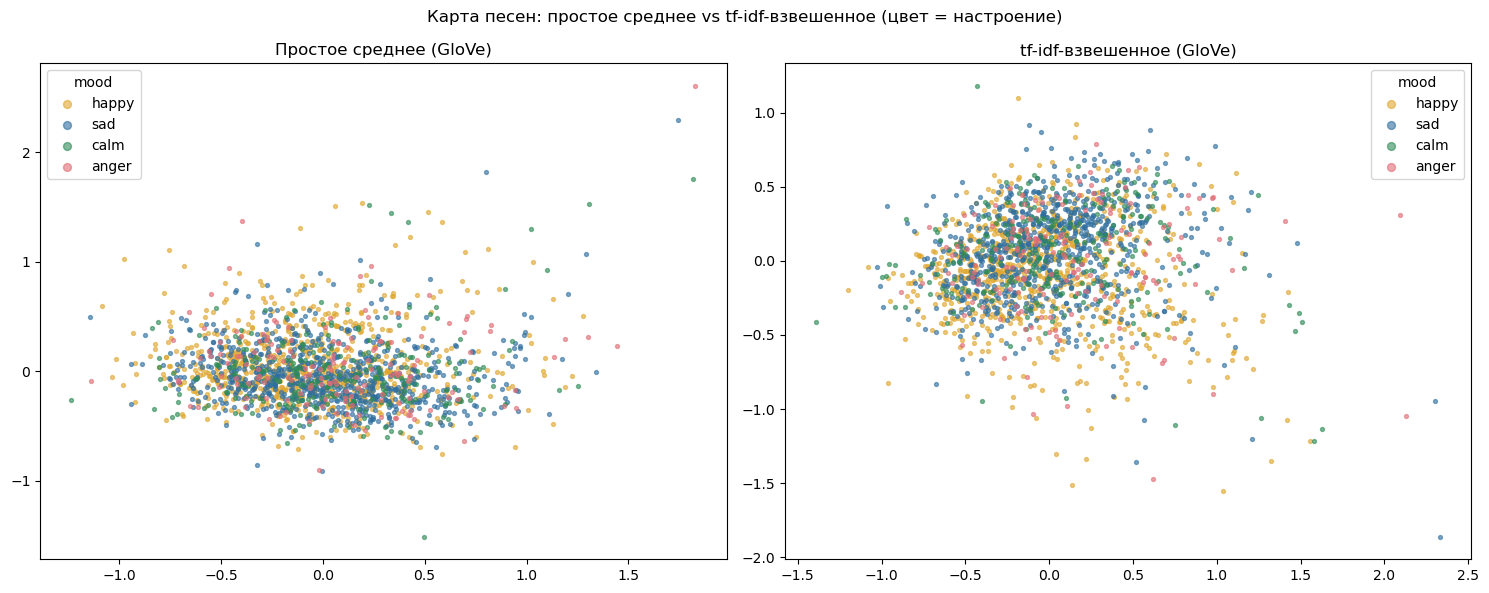

In [21]:
# карта рядом: простое среднее vs tf-idf-взвешенное (PCA, цвет = настроение)
moods_arr = np.array(moods)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, vectors, title in [
    (axes[0], songVectors,  "Простое среднее (GloVe)"),
    (axes[1], tfidfVectors, "tf-idf-взвешенное (GloVe)"),
]:
    coords = PCA(n_components=2).fit_transform(vectors)
    for m, color in palette.items():
        mask = moods_arr == m
        ax.scatter(coords[mask, 0], coords[mask, 1], s=8, color=color, alpha=0.6, label=m)
    ax.set_title(title)
    ax.legend(title="mood", markerscale=2)
plt.suptitle("Карта песен: простое среднее vs tf-idf-взвешенное (цвет = настроение)")
plt.tight_layout()
plt.savefig("outputs/compare_tfidf.png", dpi=120)
print("сохранено: outputs/compare_tfidf.png")
plt.show()

**Вывод сравнения:** tf-idf-взвешивание заметно меняет **результаты поиска** — поднимаются
более *характерные* совпадения (на «war fight blood» всплывает песня *Civil War*, которую
простое среднее не находило) и косинусные баллы выше. Но **карта по настроению остаётся кашей**
в обоих случаях: tf-idf убирает шум от частых слов, но не добавляет эмоцию, которой нет в
усреднённых статических эмбеддингах. Итог: взвешивание помогает **точности поиска**, но не
решает проблему **разделения настроения** — для неё нужны контекстные модели (BERT и т.п.).